In [1]:
import rich
import logging
import glob

import matplotlib.pyplot as plt
import time
import os
import awkward as ak
import numpy as np
import pandas as pd
from lgdo import lh5
from legendmeta import LegendMetadata
from dbetto import Props
from pygama.pargen.AoE_cal import *
from pygama.pargen.AoE_cal import CalAoE, Pol1, SigmaFit, aoe_peak
from pygama.pargen.data_cleaning import get_tcm_pulser_ids
from pygama.pargen.utils import load_data
from tqdm import tqdm

%matplotlib inline

logging.basicConfig(level=logging.INFO)
logging.getLogger('numba').setLevel(logging.INFO)
logging.getLogger('parse').setLevel(logging.INFO)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.12/site-packages/tornado

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



# Function

In [2]:
def single_plot(data, par, title = "xxx", cmax = 6):
        
    classifier = data[f"classifier_{par}"]
    
    plt.figure(figsize=(12,6), dpi=300)
    
    m_all = ~data["is_discharge"]
    m_pl = m_all & data["is_pulser"]
    m_ft = m_all & data["forced_trigger"]
    m_clean = m_all & ~data["forced_trigger"] & ~data["is_pulser"] & data["is_below_500keV"]
    
    mask_25_50 = (data["cuspEmax_ctc_cal"] >= 25) & (data["cuspEmax_ctc_cal"] <= 50)
    m_very_low = (
        m_all
        & ~data["forced_trigger"]
        & ~data["is_pulser"]
        & mask_25_50
    )
    
    m_above_500 = (
        m_all
        & ~data["forced_trigger"]
        & ~data["is_pulser"]
        & (data["cuspEmax_ctc_cal"] >= 500)
    )
    
    m_above_50_500 = (
        m_all
        & ~data["forced_trigger"]
        & ~data["is_pulser"]
        & (data["cuspEmax_ctc_cal"] >= 50) & (data["cuspEmax_ctc_cal"] <= 500)
    )
    
    
    
    cmin = -6
    #cmax = 1000
    bins = 500
    
    
    plt.hist(classifier[m_all], bins=bins, range=(cmin, cmax), histtype='step', label='All >25 keV')
    plt.hist(classifier[m_all & m_pl], bins=bins, range=(cmin, cmax), histtype='step', label='PL')
    plt.hist(classifier[m_all & m_ft], bins=bins, range=(cmin, cmax), histtype='step', label='FT')
    #plt.hist(classifier[m_above_50_500], bins=bins, range=(cmin, cmax), histtype='step', label='~PL & ~FT & 50 < <500 keV')
    #plt.hist(classifier[m_very_low], bins=bins, range=(cmin, cmax), histtype='step', color = 'deepskyblue', label='~PL & ~FT & 25 < <50 keV')
    plt.hist(classifier[m_clean], bins=bins, range=(cmin, cmax), histtype='step', label='~PL & ~FT & >500 keV')
    
    
    plt.axvspan(-25, -5, color = 'grey', alpha=0.15)
    plt.axvspan(5,cmax, color = 'grey', alpha=0.15)
    plt.xticks(range(0,1001, 50))
    plt.vlines(-5, 0, 5e3, ls = '--', color = 'grey' )
    plt.vlines(5, 0, 5e3, ls = '--', color = 'grey', label = 'Classifier CUT' )
    plt.ylabel('Counts')
    plt.title(f"{title} : r000 + r001")
    plt.xlabel(f'Classifier {par}')
    plt.yscale('log')
    plt.xlim(cmin, cmax)
    plt.legend(loc = 'upper right', fontsize = 12)

    return

In [3]:
def energy_spectrum_cut_plot(data, classifier_par):

    plt.figure(figsize=(16,6), dpi=300)

    
    ene = data['cuspEmax_ctc_cal']
    
    m_discharge = ~data["is_discharge"]
    m_pulser = data["is_pulser"]
    m_ft = data["forced_trigger"]
    m_lowE = data["is_below_500keV"]
    m_fix = data["is_HPGe"]&~data["is_muon"]
    m_classifier = data[f"is_valid_{classifier_par}"]
    
    
    CUT = len(ene[m_discharge & ~m_pulser & ~m_ft & m_fix & ~m_classifier]) * 100/ len(ene[m_discharge & ~m_pulser & ~m_ft & m_fix])
    PASS = len(ene[m_discharge & ~m_pulser & ~m_ft & m_fix & m_classifier]) * 100/ len(ene[m_discharge & ~m_pulser & ~m_ft & m_fix])
    
    emin = -1000
    emax = 6000
    bins = int((emax-emin)/10)
    
    
    plt.hist(ene[m_discharge & ~m_pulser & ~m_ft & m_fix], 
             bins = bins, 
             range=(emin, emax), 
             histtype = 'step',
             color = 'gray',
             label = f'All {len(ene[m_discharge & ~m_pulser & ~m_ft & m_fix])}'
            )
    
    plt.hist(ene[m_discharge & ~m_pulser & ~m_ft & m_fix & m_classifier], 
             bins = bins, 
             range=(emin, emax), 
             histtype = 'step',
             color = 'deepskyblue',
             label = f'is_valid_{classifier_par} {len(ene[m_discharge & ~m_pulser & ~m_ft & m_fix & m_classifier])}, PASS={PASS:.3f}%'
            )
    
    plt.hist(ene[m_discharge & ~m_pulser & ~m_ft & m_fix & ~m_classifier], 
             bins = bins, 
             range=(emin, emax), 
             histtype = 'step',
             color = 'brown',
             label = f'~is_valid_{classifier_par} {len(ene[m_discharge & ~m_pulser & ~m_ft & m_fix & ~m_classifier])}, CUT={CUT:.3f}%'
            )
    
    plt.legend(loc = 'upper right')
    plt.xlabel('Energy [keV]')
    plt.ylabel('Counts / 10 keV')
    plt.title(f'{classifier_par} cut')
    plt.xlim(emin, emax)
    plt.yscale('log')

    

# Get data

In [4]:
from pathlib import Path

folders = ["Parquet data r000", "Parquet data r001"]

for folder in folders:
    for f in Path(folder).glob("*.parquet"):
        print(f, f.stat().st_mtime)

Parquet data r000/data_ICPC_phy_ALL.parquet 1780846464.9870553
Parquet data r000/data_BEGe_phy_ALL.parquet 1780846868.3244407
Parquet data r000/data_Coax_phy_ALL.parquet 1780847255.1434295
Parquet data r000/data_PPC_phy_ALL.parquet 1780847170.264792
Parquet data r001/data_ICPC_phy_ALL.parquet 1780846696.864738
Parquet data r001/data_BEGe_phy_ALL.parquet 1780847132.930725
Parquet data r001/data_Coax_phy_ALL.parquet 1780846090.1692038
Parquet data r001/data_PPC_phy_ALL.parquet 1780847446.6567166


In [5]:
from pathlib import Path

for folder in folders:
    print(folder)
    print(Path(folder).resolve())

Parquet data r000
/global/u2/r/ritaferi/Low Energy QC/Baseline/Parquet data r000
Parquet data r001
/global/u2/r/ritaferi/Low Energy QC/Baseline/Parquet data r001


In [6]:
for folder in folders:
    file = Path(folder) / "data_Coax_phy_ALL.parquet"
    print(file.resolve())

/global/u2/r/ritaferi/Low Energy QC/Baseline/Parquet data r000/data_Coax_phy_ALL.parquet
/global/u2/r/ritaferi/Low Energy QC/Baseline/Parquet data r001/data_Coax_phy_ALL.parquet


In [7]:
from pathlib import Path
import pandas as pd

folders = ["Parquet data r000", "Parquet data r001"]
#folders = ["data r000"]

def load_detector(filename):
    return pd.concat(
        [pd.read_parquet(Path(folder) / filename) for folder in folders],
        ignore_index=True
    )


In [8]:

df_coax = load_detector("data_Coax_phy_ALL.parquet")


In [9]:
df_bege = load_detector("data_BEGe_phy_ALL.parquet")


In [10]:
df_ppc  = load_detector("data_PPC_phy_ALL.parquet")


In [11]:
df_icpc = load_detector("data_ICPC_phy_ALL.parquet")



In [16]:
data_tot = [df_icpc, df_bege, df_ppc, df_coax]

In [13]:
params = ["bl_slope", 
          "bl_slope_rms",
         "tail_rms"]


# 
bl_slope

In [14]:
#single_plot(df_all,params[0] , title = "All ge waveforms", cmax = 6)

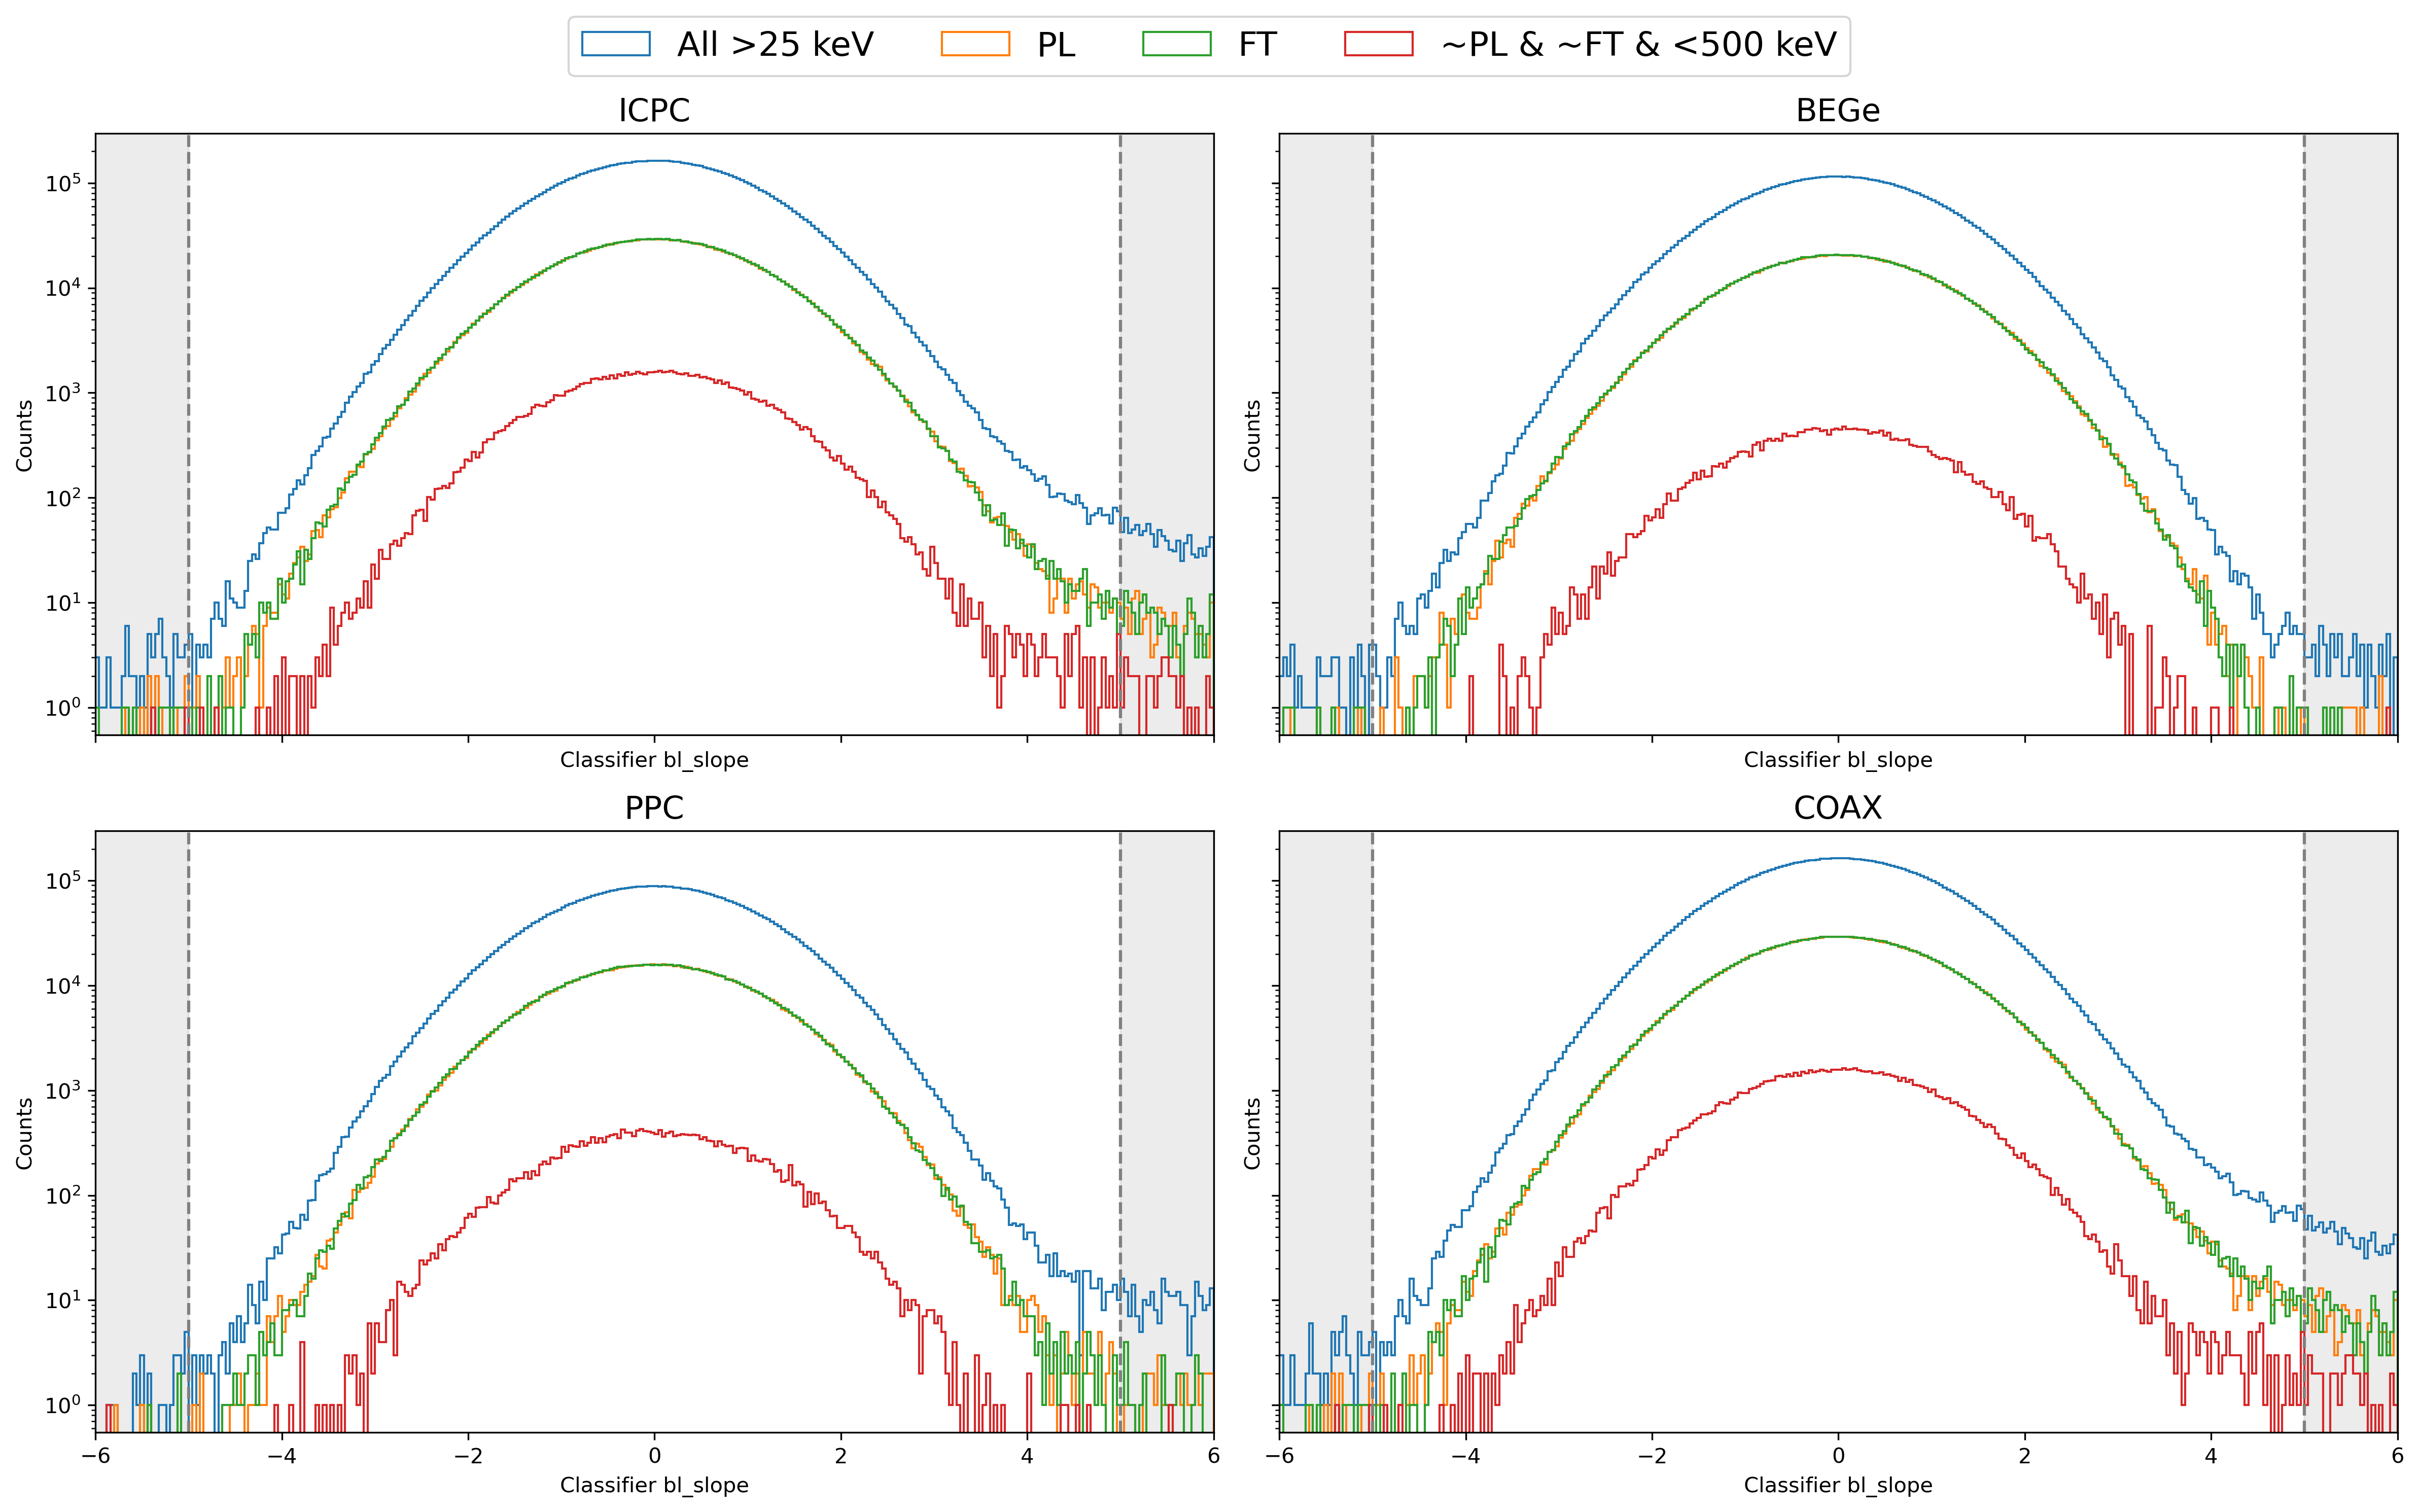

In [15]:
dfs = [df_icpc, df_bege, df_ppc, df_icpc]
titles = ["ICPC", "BEGe", "PPC", "COAX"]

par = "bl_slope"
cmax = 6

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    dpi=300,
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, data, title in zip(axes, dfs, titles):

    classifier = data[f"classifier_{par}"]

    m_discharge = ~data["is_discharge"]
    
    m_pl = m_discharge & data["is_pulser"]
    m_ft = m_discharge & data["forced_trigger"]

    m_qc = m_discharge
    
    m_clean = (
        m_qc
        & ~data["forced_trigger"]
        & ~data["is_pulser"]
        & data["is_below_500keV"]
    )

    cmin = -6
    bins = 300

    ax.hist(
        classifier[m_qc],
        bins=bins,
        range=(cmin, cmax),
        histtype="step",
        label="All >25 keV"
    )

    ax.hist(
        classifier[m_pl],
        bins=bins,
        range=(cmin, cmax),
        histtype="step",
        label="PL"
    )

    ax.hist(
        classifier[m_ft],
        bins=bins,
        range=(cmin, cmax),
        histtype="step",
        label="FT"
    )

    ax.hist(
        classifier[m_clean],
        bins=bins,
        range=(cmin, cmax),
        histtype="step",
        label="~PL & ~FT & <500 keV"
    )

    ax.axvspan(-25, -5, color="grey", alpha=0.15)
    ax.axvspan(5, cmax, color="grey", alpha=0.15)

    ax.axvline(-5, ls="--", color="grey")
    ax.axvline(5, ls="--", color="grey")

    ax.set_yscale("log")
    ax.set_xlim(cmin, cmax)

    ax.set_title(title, fontsize = 15)
    ax.set_xlabel("Classifier bl_slope")
    ax.set_ylabel("Counts")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4,  fontsize = 16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

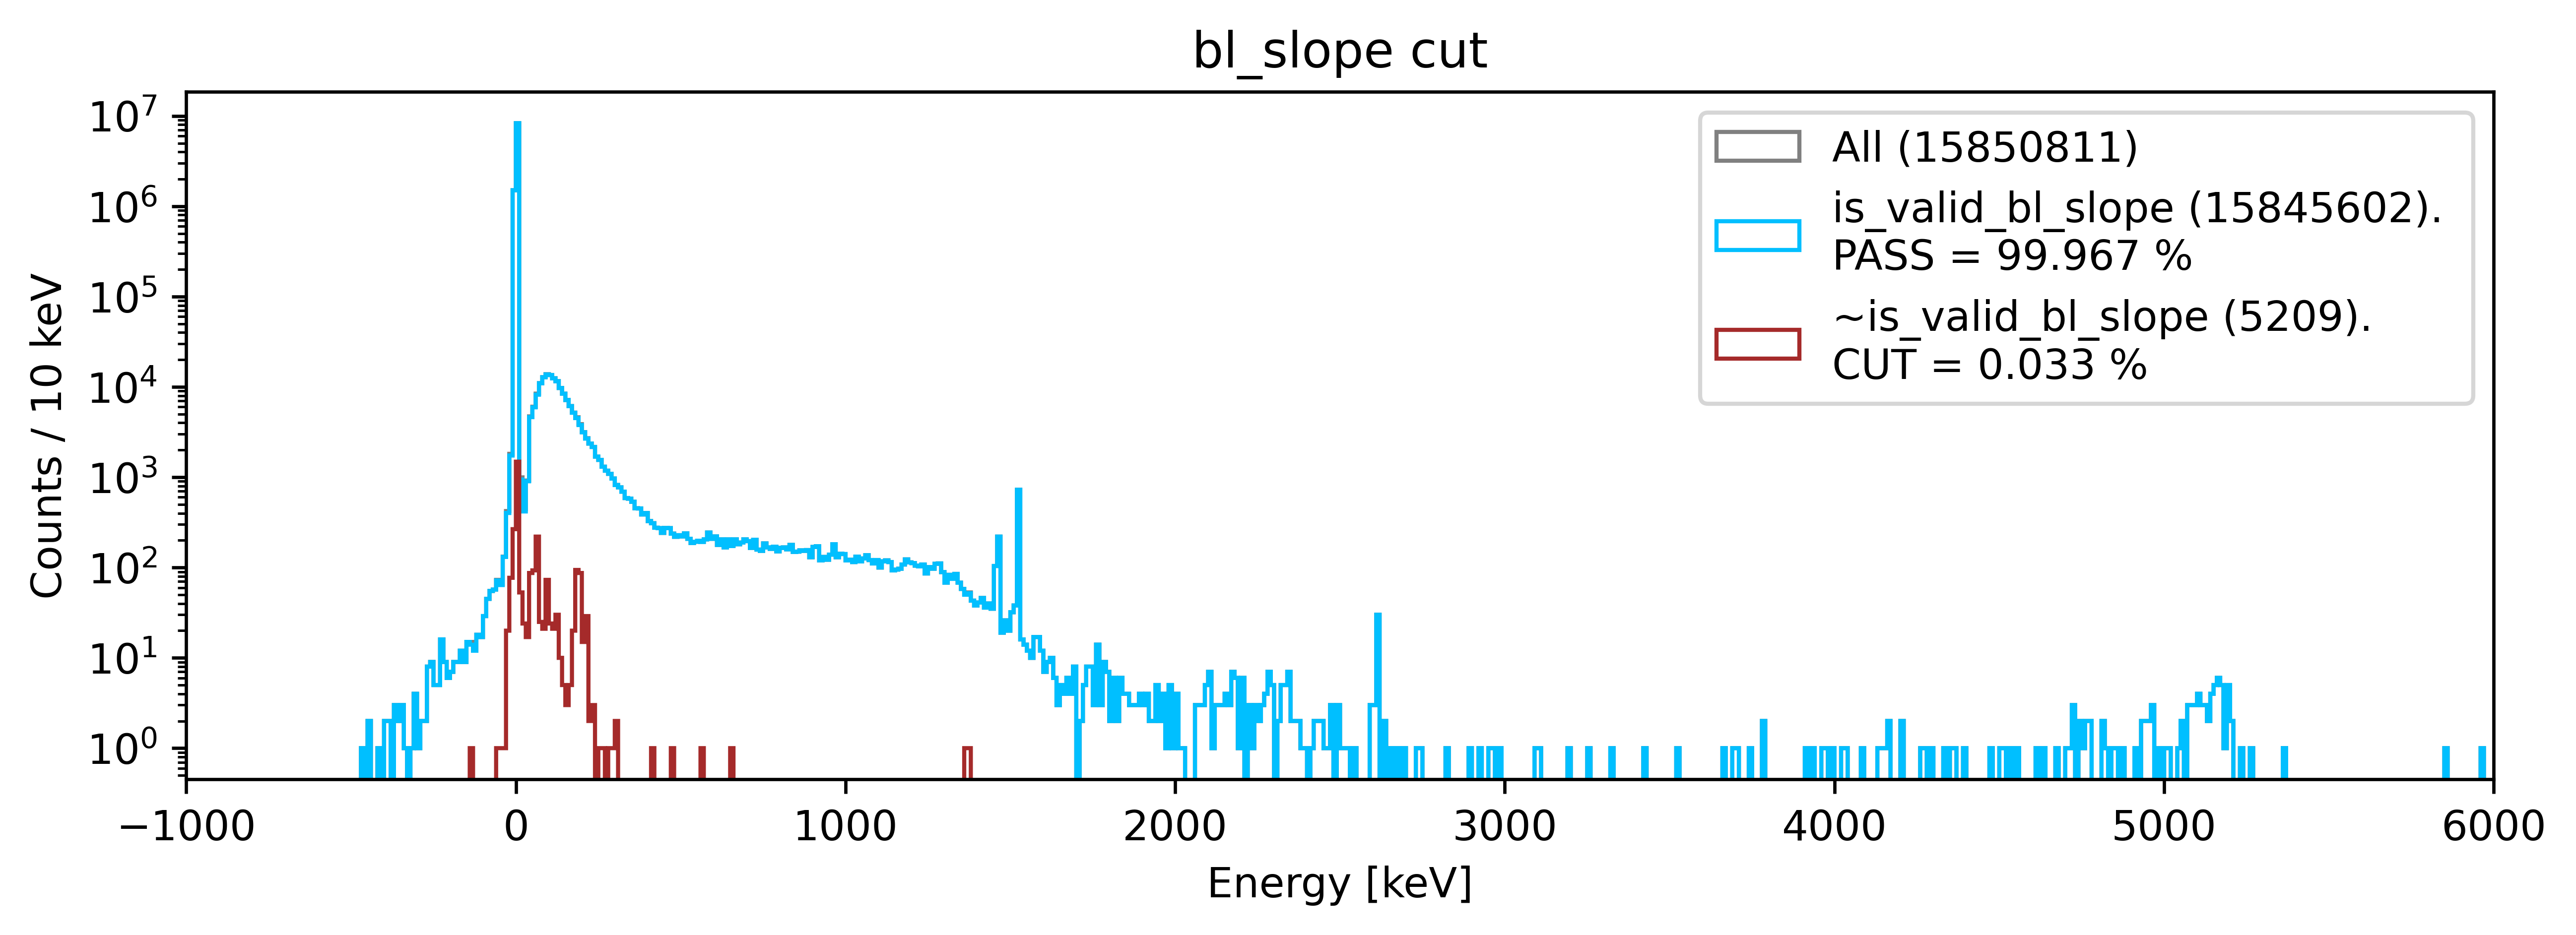

In [27]:
ene_all_list = []
ene_valid_all = []
ene_not_valid_all = []

for data in data_tot:

    fixed_mask = (~data["forced_trigger"] & ~data["is_pulser"] & data["is_HPGe"]&~data["is_muon"])
    studied_qc = ~data["is_discharge"]
    new_qc = data["is_valid_bl_slope"]

    mask = fixed_mask & studied_qc

    # energia selezionata
    ene_all = data.loc[mask, "cuspEmax_ctc_cal"]

    qc = new_qc[mask].values

    ene_all_list.append(ene_all.to_numpy())
    ene_valid_all.append(ene_all[qc].to_numpy())
    ene_not_valid_all.append(ene_all[~qc].to_numpy())

# --- UNICI ARRAY FINALI ---
ene_all = np.concatenate(ene_all_list)
ene_valid_all = np.concatenate(ene_valid_all)
ene_not_valid_all = np.concatenate(ene_not_valid_all)

# --- PLOT ---

emin = -1000
emax = 6000
bins = int((emax-emin)/10)

PASS = len(ene_valid_all) * 100 / len(ene_all)
CUT = len(ene_not_valid_all) * 100 / len(ene_all)

plt.figure(figsize = (10,3), dpi = 600)

plt.hist(ene_all, bins=bins, histtype="step", range = (emin, emax), color = 'grey', label=f"All ({len(ene_all)}) ")
plt.hist(ene_valid_all, bins=bins, histtype="step", range = (emin, emax), color = 'deepskyblue', label=f"is_valid_bl_slope ({len(ene_valid_all)}). \nPASS = {PASS:.3f} %")
plt.hist(ene_not_valid_all, bins=bins, histtype="step", range = (emin, emax), color = 'brown', label=f"~is_valid_bl_slope ({len(ene_not_valid_all)}). \nCUT = {CUT:.3f} %")

plt.legend(loc = 'upper right')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts / 10 keV')
plt.title(f'bl_slope cut')
plt.xlim(emin, emax)
plt.yscale('log')

# BL_SLOPE_RMS

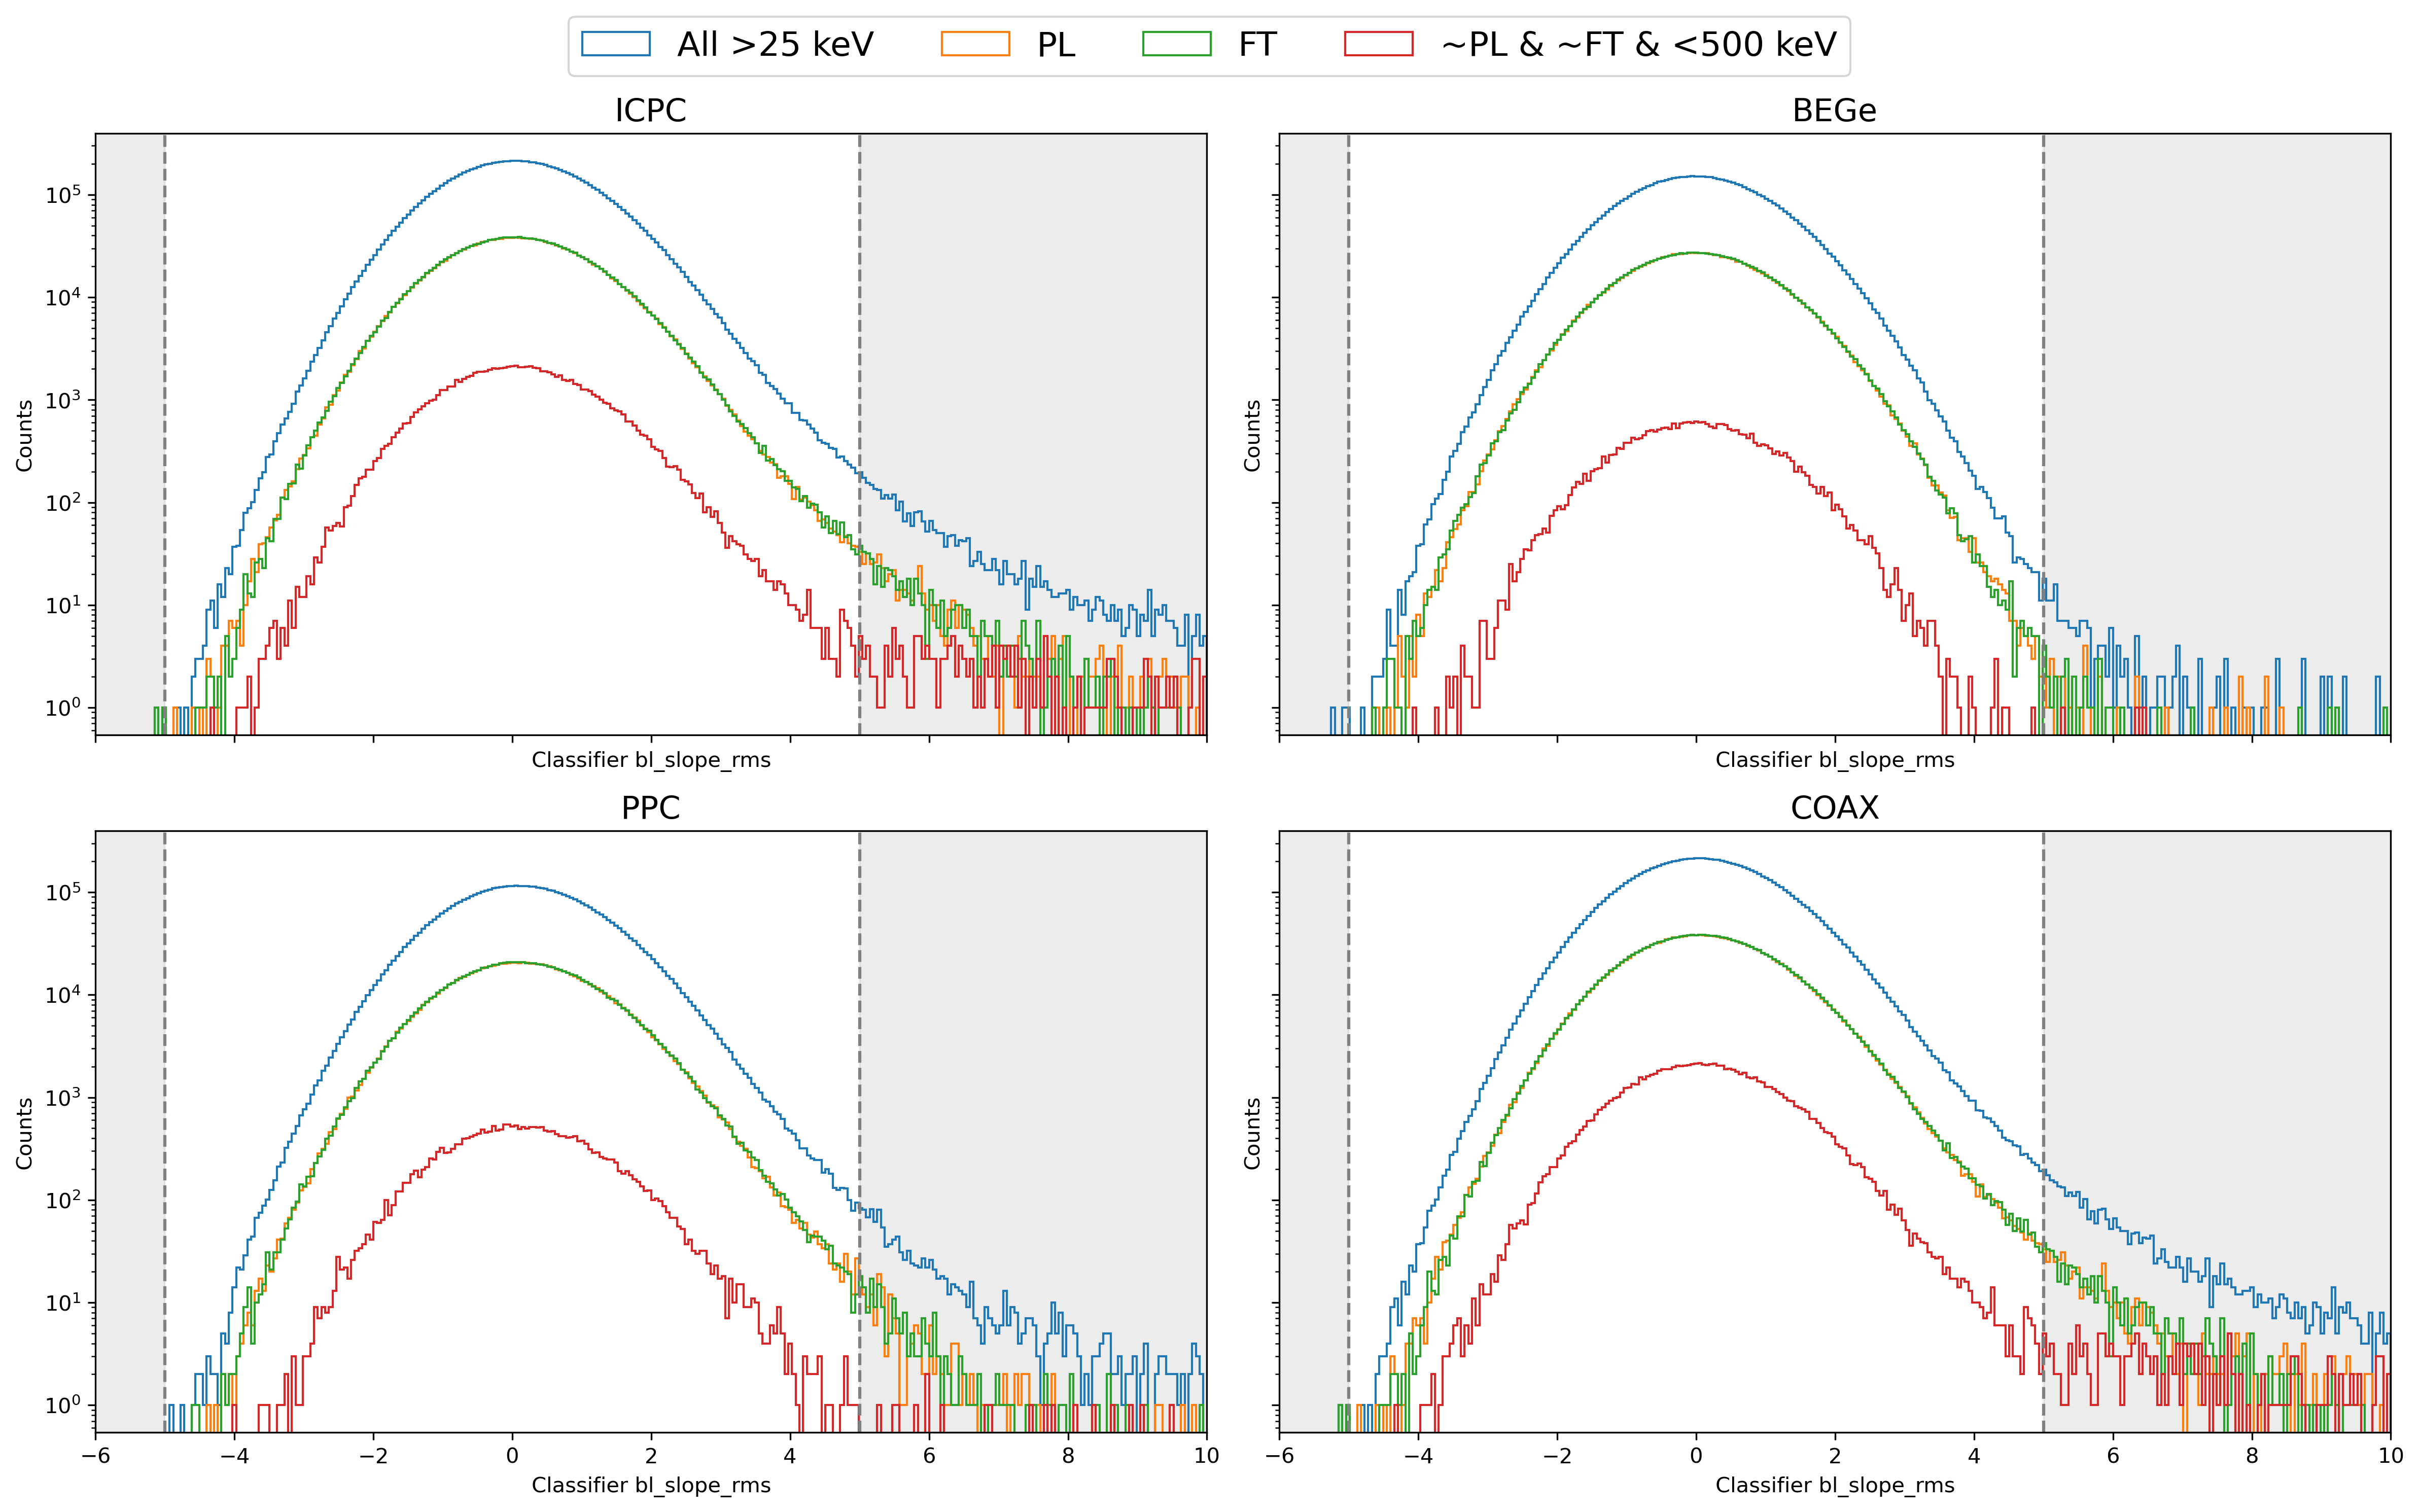

In [35]:
dfs = [df_icpc, df_bege, df_ppc, df_icpc]
titles = ["ICPC", "BEGe", "PPC", "COAX"]

par = "bl_slope_rms"
cmax = 10

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    dpi=300,
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, data, title in zip(axes, dfs, titles):

    classifier = data[f"classifier_{par}"]

    m_discharge = ~data["is_discharge"]
    
    m_pl = m_discharge & data["is_pulser"]
    m_ft = m_discharge & data["forced_trigger"]

    m_bl_slope = data["is_valid_bl_slope"]
    m_qc = m_discharge & m_bl_slope
    
    m_clean = (
        m_qc
        & ~data["forced_trigger"]
        & ~data["is_pulser"]
        & data["is_below_500keV"]
    )

    cmin = -6
    bins = 300

    ax.hist(
        classifier[m_qc],
        bins=bins,
        range=(cmin, cmax),
        histtype="step",
        label="All >25 keV"
    )

    ax.hist(
        classifier[m_pl],
        bins=bins,
        range=(cmin, cmax),
        histtype="step",
        label="PL"
    )

    ax.hist(
        classifier[m_ft],
        bins=bins,
        range=(cmin, cmax),
        histtype="step",
        label="FT"
    )

    ax.hist(
        classifier[m_clean],
        bins=bins,
        range=(cmin, cmax),
        histtype="step",
        label="~PL & ~FT & <500 keV"
    )

    ax.axvspan(-25, -5, color="grey", alpha=0.15)
    ax.axvspan(5, cmax, color="grey", alpha=0.15)

    ax.axvline(-5, ls="--", color="grey")
    ax.axvline(5, ls="--", color="grey")

    ax.set_yscale("log")
    ax.set_xlim(cmin, cmax)

    ax.set_title(title, fontsize = 15)
    ax.set_xlabel("Classifier bl_slope_rms")
    ax.set_ylabel("Counts")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4,  fontsize = 16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

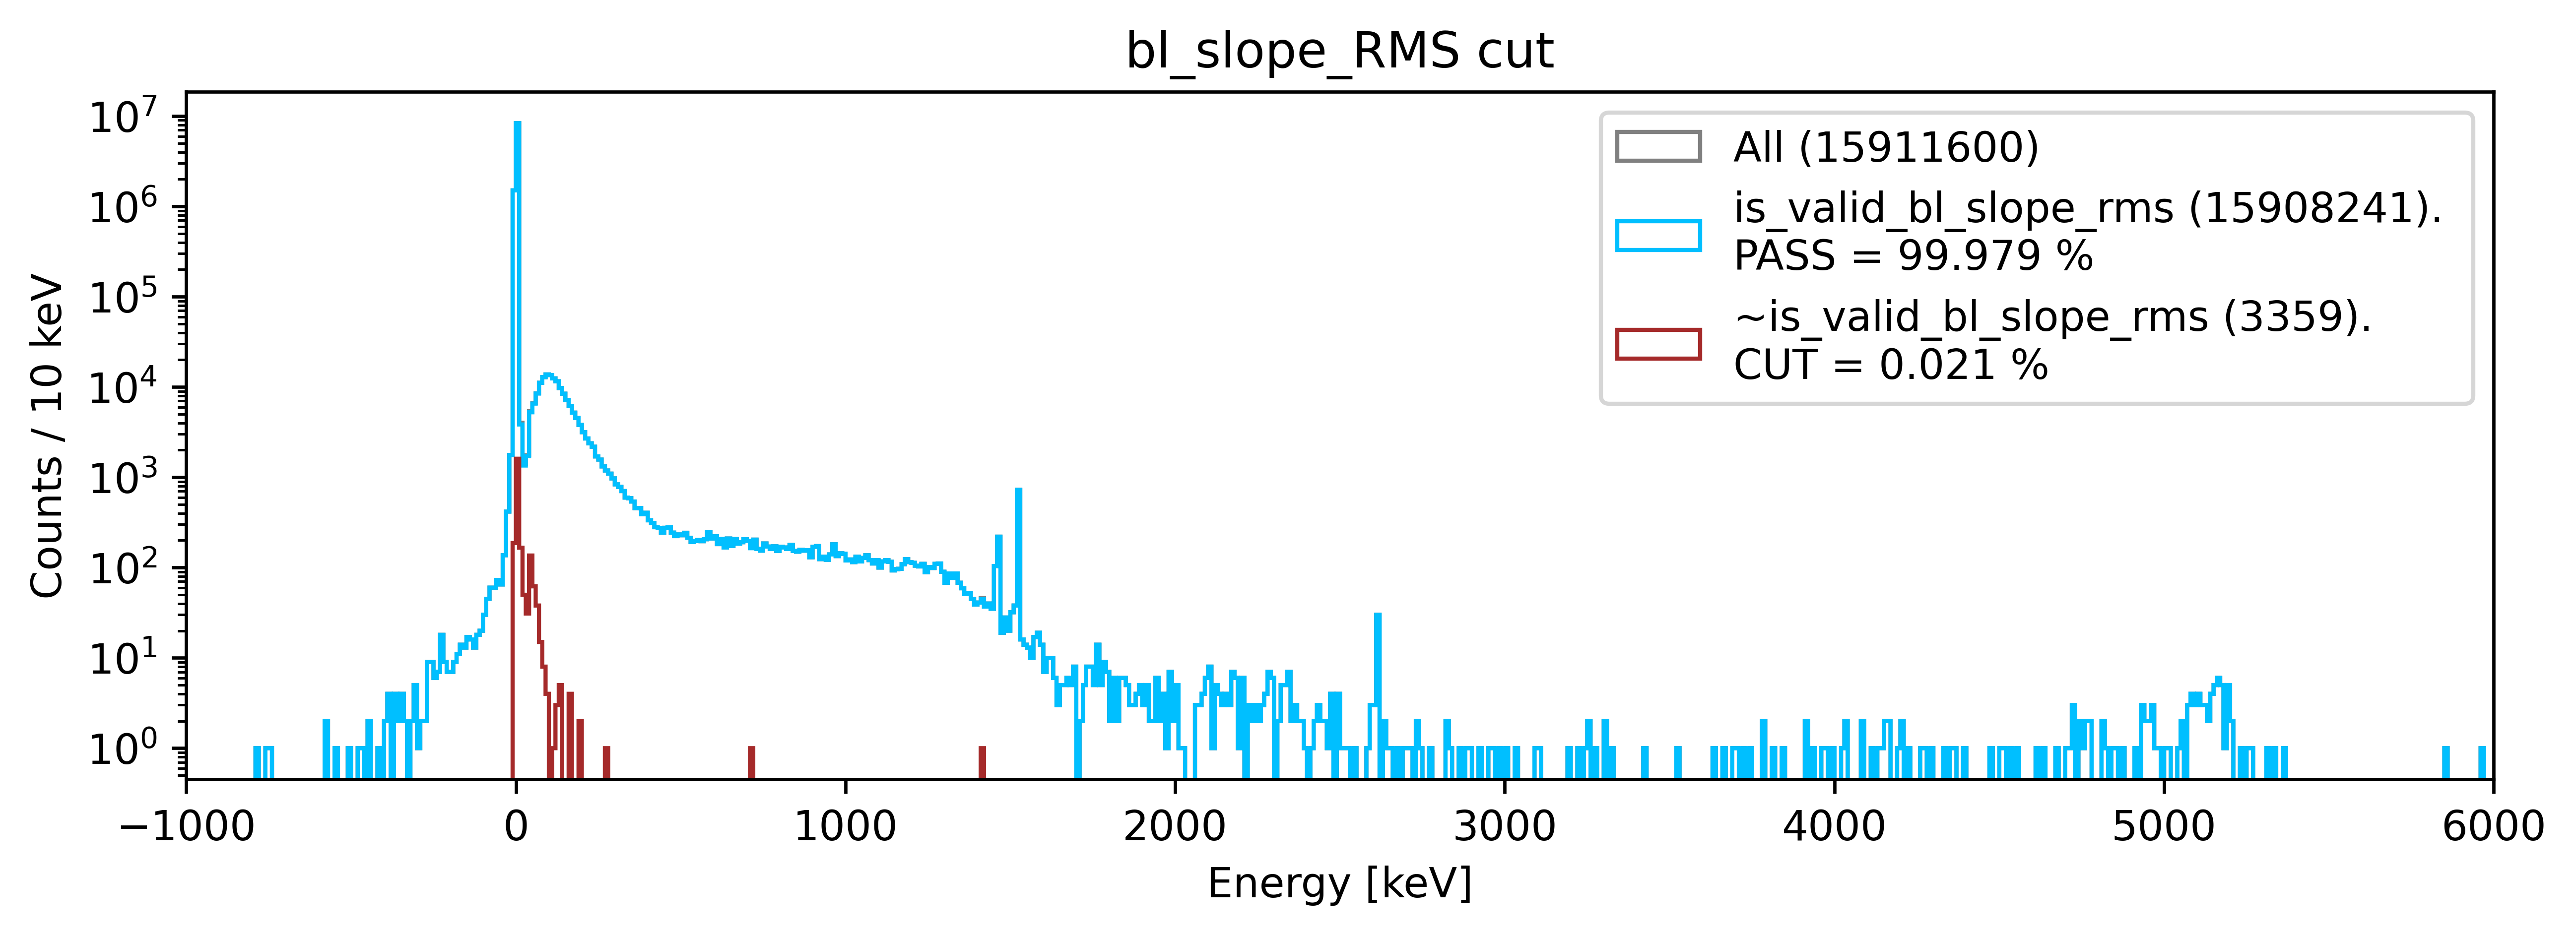

In [40]:
ene_all_list = []
ene_valid_all = []
ene_not_valid_all = []

for data in data_tot:

    fixed_mask = (~data["forced_trigger"] & ~data["is_pulser"])# & data["is_HPGe"]&~data["is_muon"])
    studied_qc = ~data["is_discharge"] & data["is_valid_bl_slope"]
    new_qc = data["is_valid_bl_slope_rms"]

    mask = fixed_mask & studied_qc

    # energia selezionata
    ene_all = data.loc[mask, "cuspEmax_ctc_cal"]

    qc = new_qc[mask].values

    ene_all_list.append(ene_all.to_numpy())
    ene_valid_all.append(ene_all[qc].to_numpy())
    ene_not_valid_all.append(ene_all[~qc].to_numpy())

# --- UNICI ARRAY FINALI ---
ene_all = np.concatenate(ene_all_list)
ene_valid_all = np.concatenate(ene_valid_all)
ene_not_valid_all = np.concatenate(ene_not_valid_all)

# --- PLOT ---

emin = -1000
emax = 6000
bins = int((emax-emin)/10)

PASS = len(ene_valid_all) * 100 / len(ene_all)
CUT = len(ene_not_valid_all) * 100 / len(ene_all)

plt.figure(figsize = (10,3), dpi = 600)

plt.hist(ene_all, bins=bins, histtype="step", range = (emin, emax), color = 'grey', label=f"All ({len(ene_all)}) ")
plt.hist(ene_valid_all, bins=bins, histtype="step", range = (emin, emax), color = 'deepskyblue', label=f"is_valid_bl_slope_rms ({len(ene_valid_all)}). \nPASS = {PASS:.3f} %")
plt.hist(ene_not_valid_all, bins=bins, histtype="step", range = (emin, emax), color = 'brown', label=f"~is_valid_bl_slope_rms ({len(ene_not_valid_all)}). \nCUT = {CUT:.3f} %")

plt.legend(loc = 'upper right')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts / 10 keV')
plt.title(f'bl_slope_RMS cut')
plt.xlim(emin, emax)
plt.yscale('log')

# TAIL_RMS

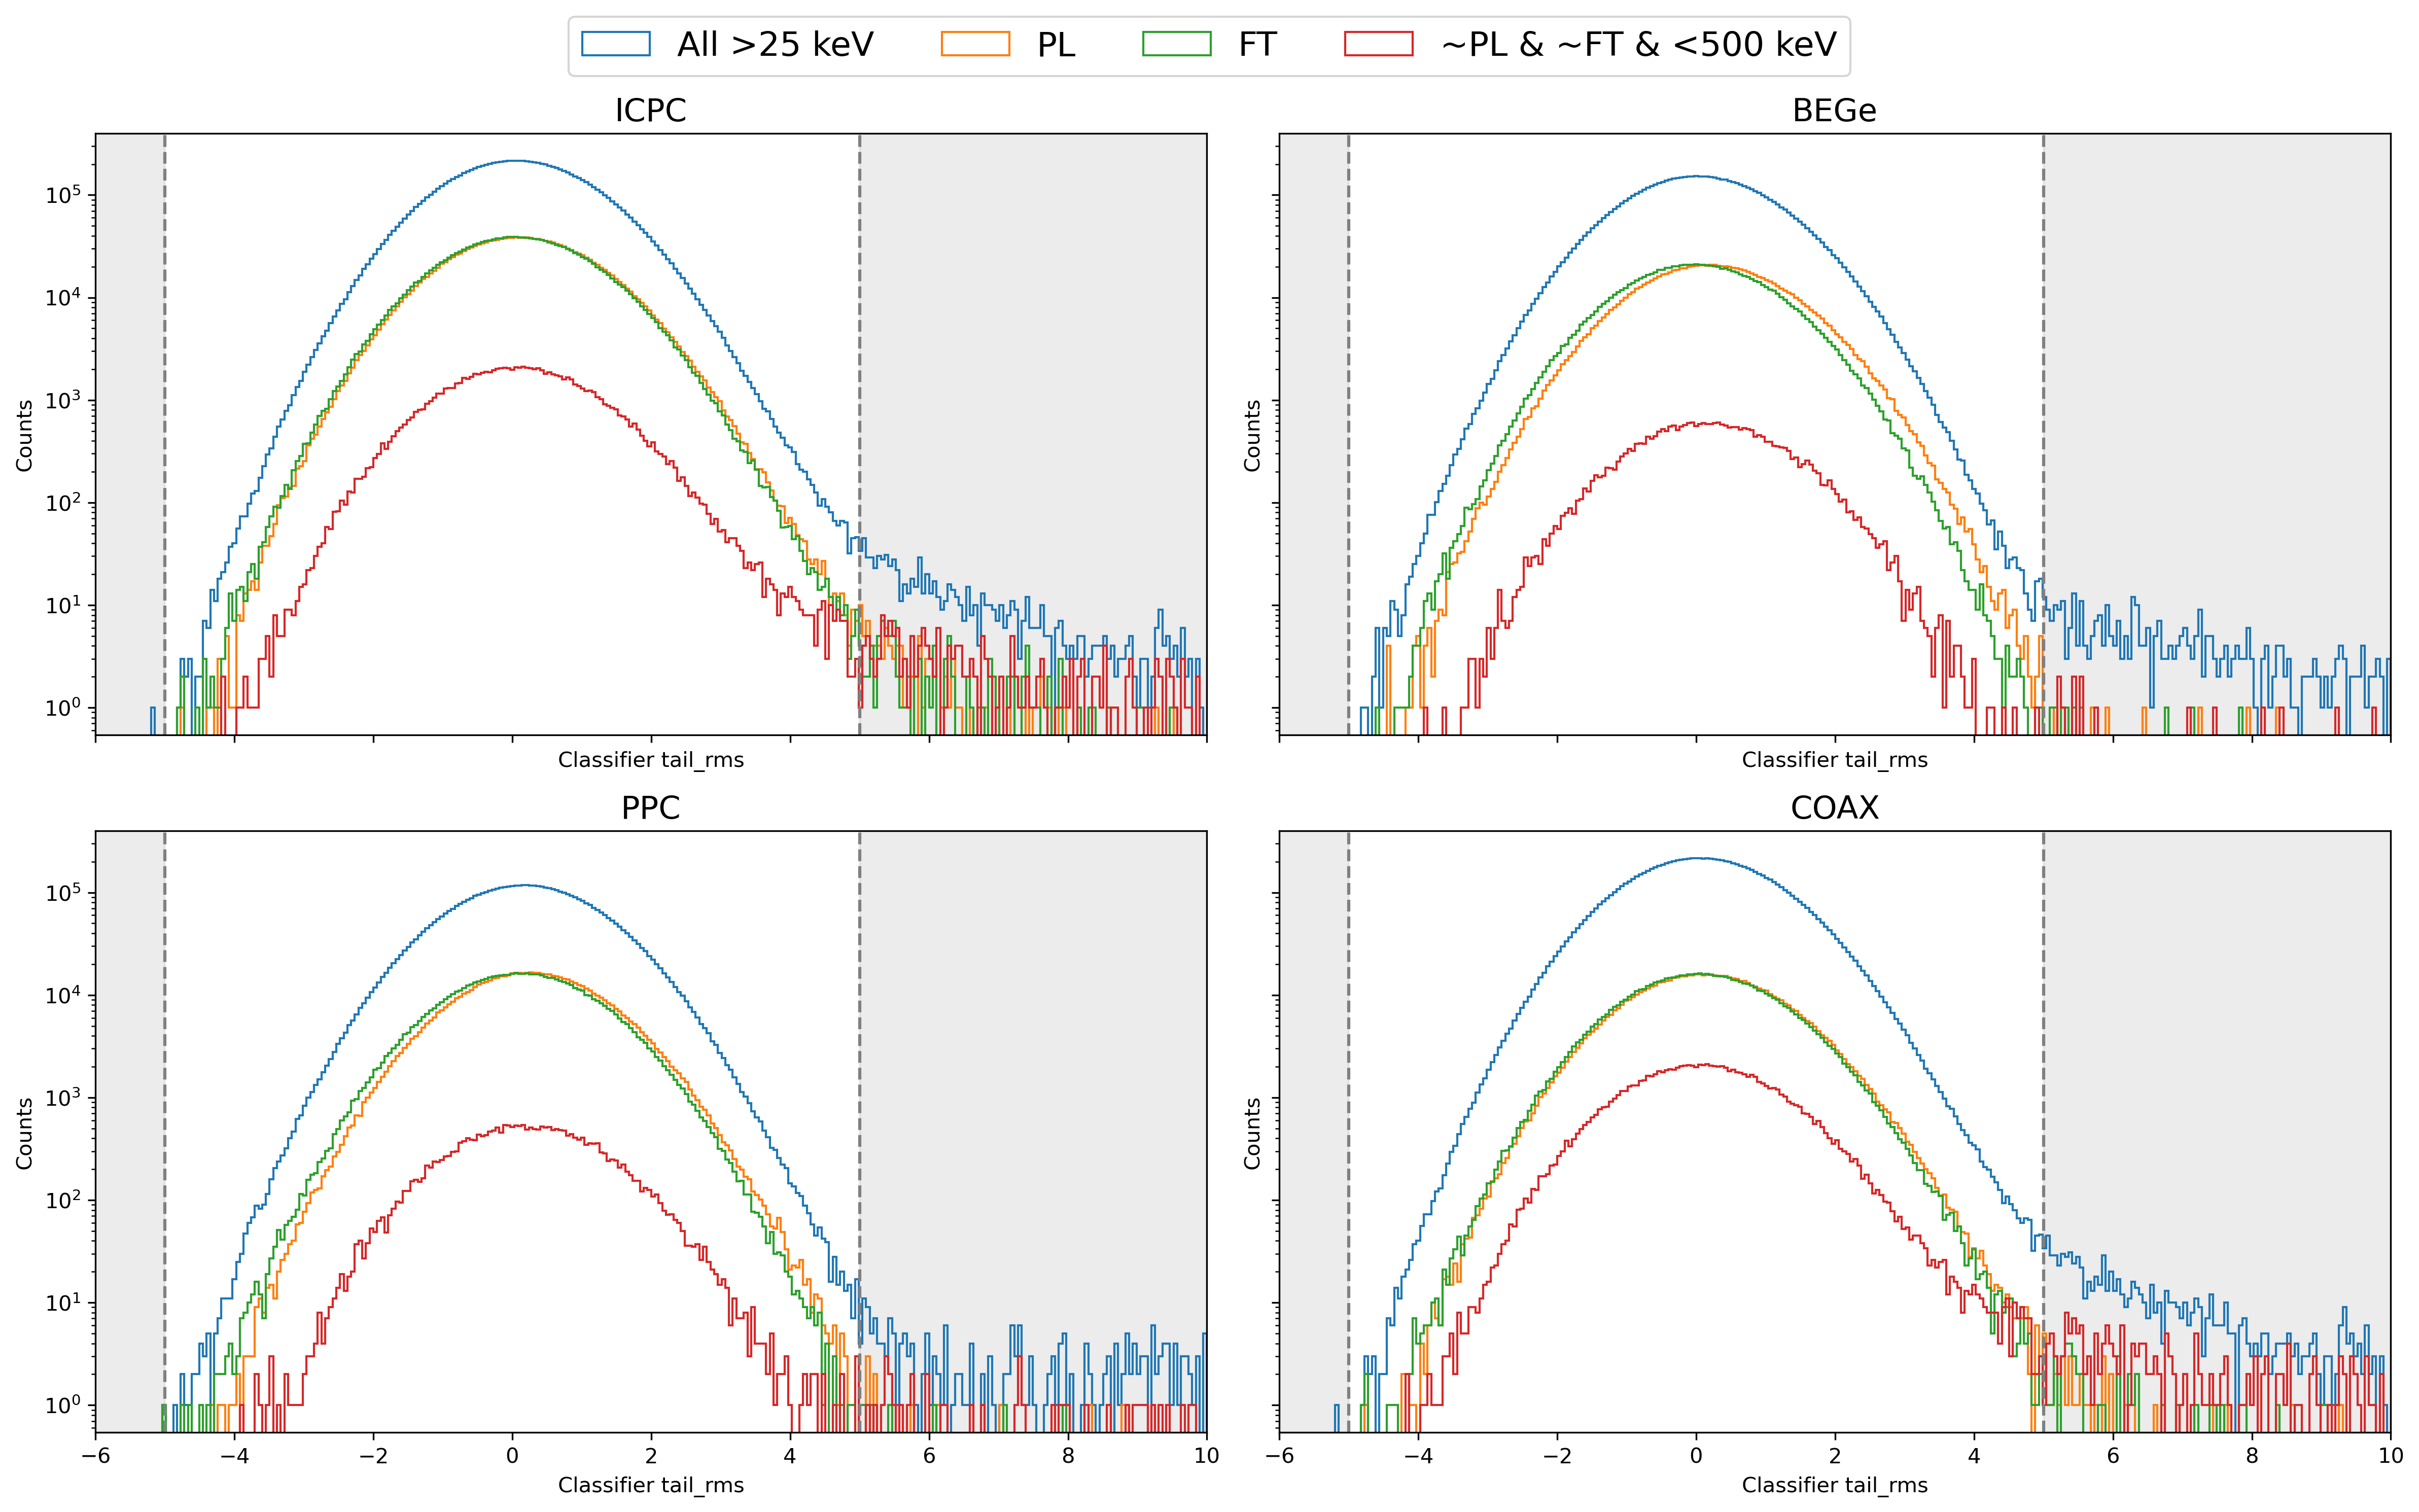

In [48]:
dfs = [df_icpc, df_bege, df_ppc, df_icpc]
titles = ["ICPC", "BEGe", "PPC", "COAX"]

par = "tail_rms"
cmax = 10

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    dpi=300,
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, data, title in zip(axes, dfs, titles):

    classifier = data[f"classifier_{par}"]
    
    
    m_pl = m_discharge & data["is_pulser"]
    m_ft = m_discharge & data["forced_trigger"]

    m_discharge = ~data["is_discharge"]
    m_bl_slope = data["is_valid_bl_slope"]
    m_bl_slope_rms = data["is_valid_bl_slope_rms"]
    m_qc = m_discharge & m_bl_slope & m_bl_slope_rms
    
    m_clean = (
        m_qc
        & ~data["forced_trigger"]
        & ~data["is_pulser"]
        & data["is_below_500keV"]
    )

    cmin = -6
    bins = 300

    
    ax.hist(
        classifier[m_qc],
        bins=bins,
        range=(cmin, cmax),
        histtype="step",
        label="All >25 keV"
    )

    ax.hist(
        classifier[m_pl],
        bins=bins,
        range=(cmin, cmax),
        histtype="step",
        label="PL"
    )

    ax.hist(
        classifier[m_ft],
        bins=bins,
        range=(cmin, cmax),
        histtype="step",
        label="FT"
    )

    ax.hist(
        classifier[m_clean],
        bins=bins,
        range=(cmin, cmax),
        histtype="step",
        label="~PL & ~FT & <500 keV"
    )

    ax.axvspan(-25, -5, color="grey", alpha=0.15)
    ax.axvspan(5, cmax, color="grey", alpha=0.15)

    ax.axvline(-5, ls="--", color="grey")
    ax.axvline(5, ls="--", color="grey")

    ax.set_yscale("log")
    ax.set_xlim(cmin, cmax)

    ax.set_title(title, fontsize = 15)
    ax.set_xlabel("Classifier tail_rms")
    ax.set_ylabel("Counts")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4,  fontsize = 16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

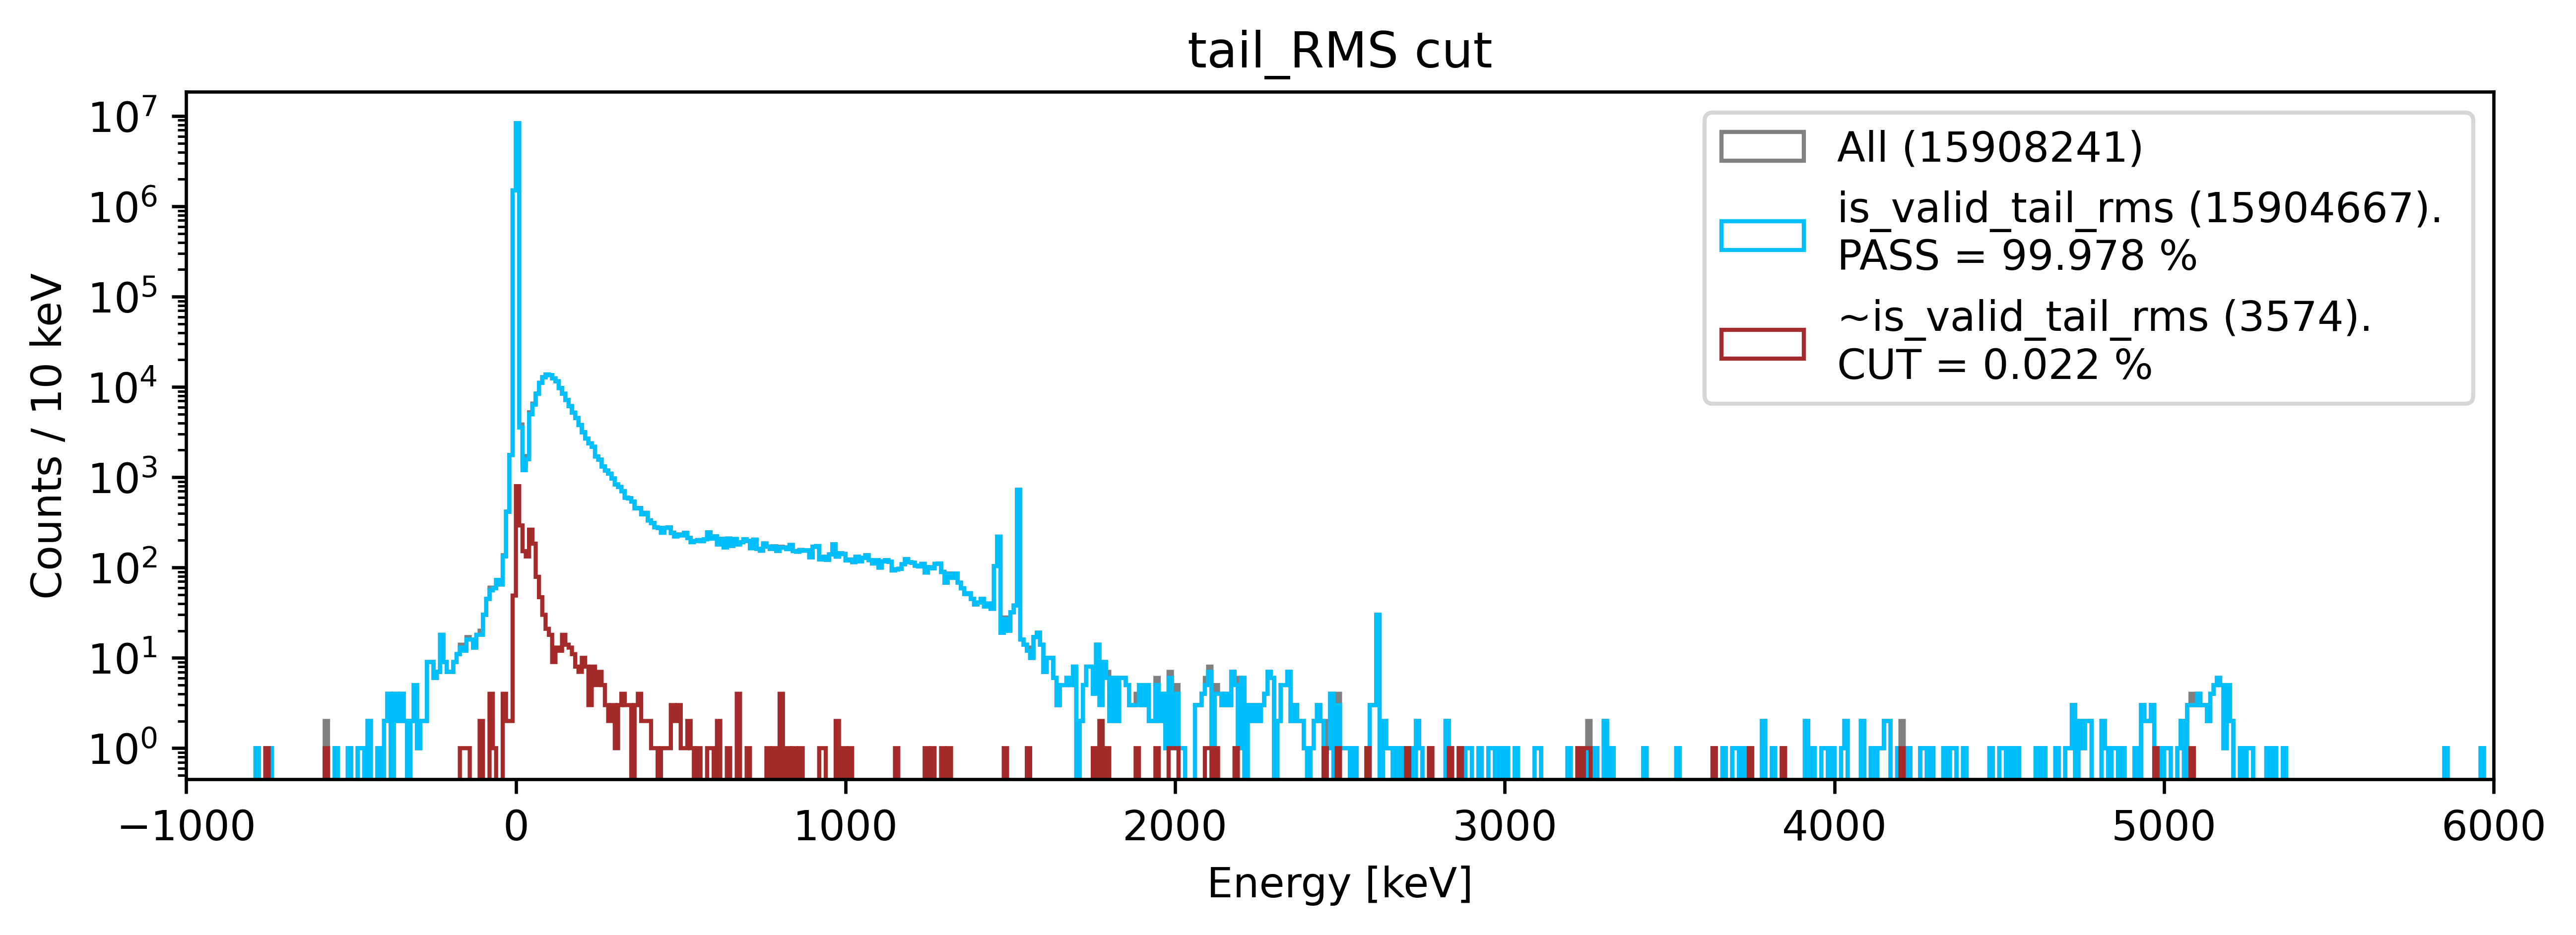

In [50]:
ene_all_list = []
ene_valid_all = []
ene_not_valid_all = []

for data in data_tot:

    fixed_mask = (~data["forced_trigger"] & ~data["is_pulser"])# & data["is_HPGe"]&~data["is_muon"])
    studied_qc = ~data["is_discharge"] & data["is_valid_bl_slope"] & data["is_valid_bl_slope_rms"]
    new_qc = data["is_valid_tail_rms"]

    mask = fixed_mask & studied_qc

    # energia selezionata
    ene_all = data.loc[mask, "cuspEmax_ctc_cal"]

    qc = new_qc[mask].values

    ene_all_list.append(ene_all.to_numpy())
    ene_valid_all.append(ene_all[qc].to_numpy())
    ene_not_valid_all.append(ene_all[~qc].to_numpy())

# --- UNICI ARRAY FINALI ---
ene_all = np.concatenate(ene_all_list)
ene_valid_all = np.concatenate(ene_valid_all)
ene_not_valid_all = np.concatenate(ene_not_valid_all)

# --- PLOT ---

emin = -1000
emax = 6000
bins = int((emax-emin)/10)

PASS = len(ene_valid_all) * 100 / len(ene_all)
CUT = len(ene_not_valid_all) * 100 / len(ene_all)

plt.figure(figsize = (10,3), dpi = 600)

plt.hist(ene_all, bins=bins, histtype="step", range = (emin, emax), color = 'grey', label=f"All ({len(ene_all)}) ")
plt.hist(ene_valid_all, bins=bins, histtype="step", range = (emin, emax), color = 'deepskyblue', label=f"is_valid_tail_rms ({len(ene_valid_all)}). \nPASS = {PASS:.3f} %")
plt.hist(ene_not_valid_all, bins=bins, histtype="step", range = (emin, emax), color = 'brown', label=f"~is_valid_tail_rms ({len(ene_not_valid_all)}). \nCUT = {CUT:.3f} %")

plt.legend(loc = 'upper right')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts / 10 keV')
plt.title(f'tail_RMS cut')
plt.xlim(emin, emax)
plt.yscale('log')

# Noise Burst

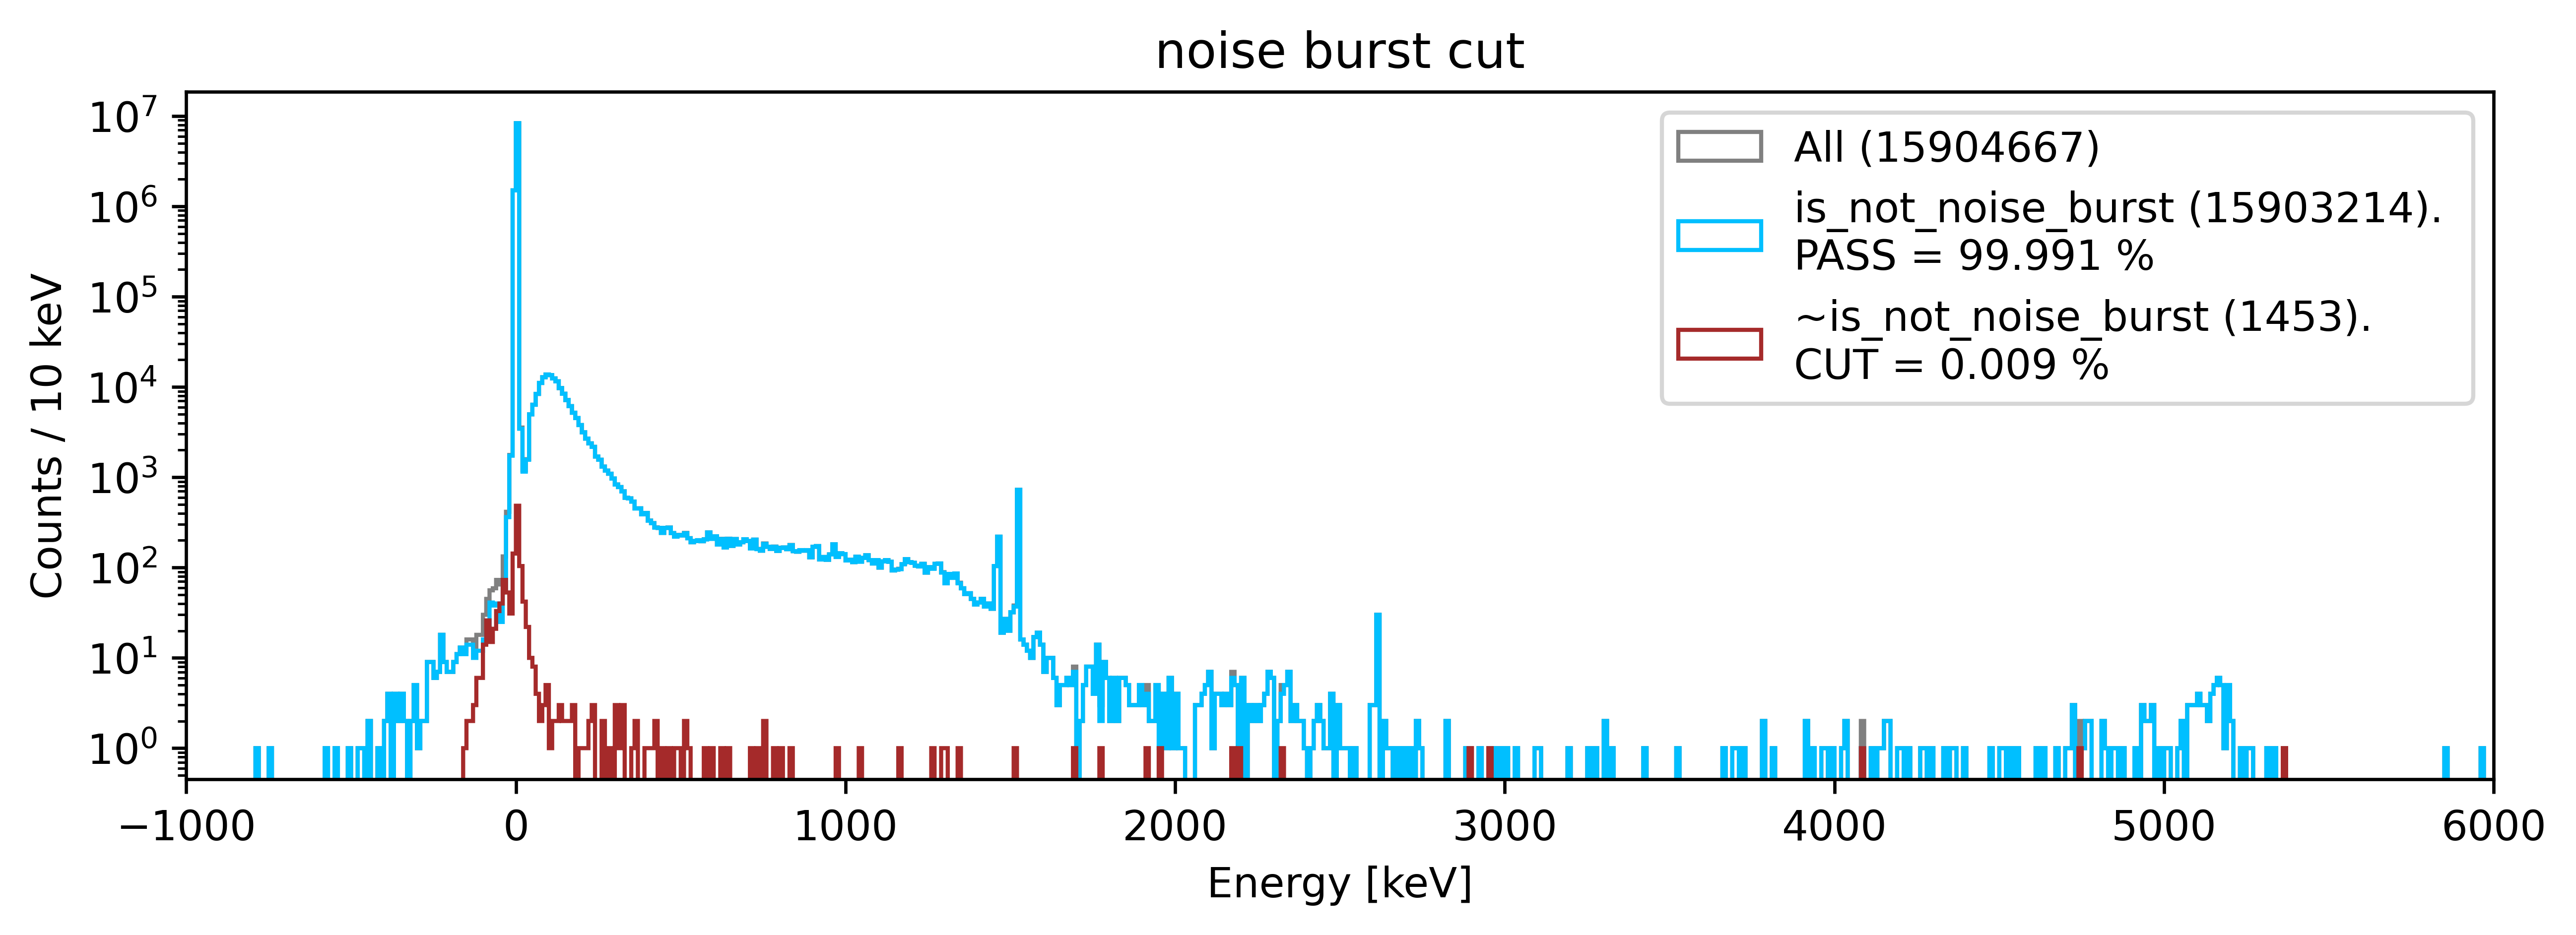

In [51]:
ene_all_list = []
ene_valid_all = []
ene_not_valid_all = []

for data in data_tot:

    fixed_mask = (~data["forced_trigger"] & ~data["is_pulser"])# & data["is_HPGe"]&~data["is_muon"])
    studied_qc = ~data["is_discharge"] & data["is_valid_bl_slope"] & data["is_valid_bl_slope_rms"] & data["is_valid_tail_rms"]
    new_qc = data["is_not_noise_burst"]

    mask = fixed_mask & studied_qc

    # energia selezionata
    ene_all = data.loc[mask, "cuspEmax_ctc_cal"]

    qc = new_qc[mask].values

    ene_all_list.append(ene_all.to_numpy())
    ene_valid_all.append(ene_all[qc].to_numpy())
    ene_not_valid_all.append(ene_all[~qc].to_numpy())

# --- UNICI ARRAY FINALI ---
ene_all = np.concatenate(ene_all_list)
ene_valid_all = np.concatenate(ene_valid_all)
ene_not_valid_all = np.concatenate(ene_not_valid_all)

# --- PLOT ---

emin = -1000
emax = 6000
bins = int((emax-emin)/10)

PASS = len(ene_valid_all) * 100 / len(ene_all)
CUT = len(ene_not_valid_all) * 100 / len(ene_all)

plt.figure(figsize = (10,3), dpi = 600)

plt.hist(ene_all, bins=bins, histtype="step", range = (emin, emax), color = 'grey', label=f"All ({len(ene_all)}) ")
plt.hist(ene_valid_all, bins=bins, histtype="step", range = (emin, emax), color = 'deepskyblue', label=f"is_not_noise_burst ({len(ene_valid_all)}). \nPASS = {PASS:.3f} %")
plt.hist(ene_not_valid_all, bins=bins, histtype="step", range = (emin, emax), color = 'brown', label=f"~is_not_noise_burst ({len(ene_not_valid_all)}). \nCUT = {CUT:.3f} %")

plt.legend(loc = 'upper right')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts / 10 keV')
plt.title(f'noise burst cut')
plt.xlim(emin, emax)
plt.yscale('log')

# Empty Energy Cut